0. Load required .py files

In [ ]:
import src.data_loader as dl
import src.strategy as strat
import src.portfolio as port
import src.performance as perf
import src.risk as risk
import src.backtesting as bt
import src.stress as st

In [2]:
import numpy as np

1. Load preferred benchmark and obtain daily return

In [3]:
tickers = ["GLD","QQQ","SPY","TLT"]
start_date = "2015-01-01"
end_date = "2025-12-31"

"""prices = dl.download_adjusted_close_prices(tickers,start_date,end_date)
dl.save_prices_to_csv(
    prices,
    "data/prices.csv"
)"""
prices = dl.load_prices_from_csv("data/prices.csv")
returns = dl.calculate_daily_returns(prices)


2. Calculate 60 day momentum, signal and position based on price

In [4]:
momentum = strat.calculate_momentum(prices, lookback=60)
signal = strat.generate_signal(prices, lookback=60)
position = strat.generate_position(signal)

print(signal.head(65).dropna())
print(position.head(65).dropna())

            GLD  QQQ  SPY  TLT
Date                          
2015-01-02    0    0    0    0
2015-01-05    0    0    0    0
2015-01-06    0    0    0    0
2015-01-07    0    0    0    0
2015-01-08    0    0    0    0
...         ...  ...  ...  ...
2015-03-31    0    1    1    1
2015-04-01    0    1    1    1
2015-04-02    0    1    1    0
2015-04-06    1    1    1    0
2015-04-07    1    1    1    1

[65 rows x 4 columns]
            GLD  QQQ  SPY  TLT
Date                          
2015-01-05  0.0  0.0  0.0  0.0
2015-01-06  0.0  0.0  0.0  0.0
2015-01-07  0.0  0.0  0.0  0.0
2015-01-08  0.0  0.0  0.0  0.0
2015-01-09  0.0  0.0  0.0  0.0
...         ...  ...  ...  ...
2015-03-31  0.0  0.0  0.0  0.0
2015-04-01  0.0  1.0  1.0  1.0
2015-04-02  0.0  1.0  1.0  1.0
2015-04-06  0.0  1.0  1.0  0.0
2015-04-07  1.0  1.0  1.0  0.0

[64 rows x 4 columns]


3. Construct portfolio based on position and calculating it's return


In [5]:
weights = port.calculate_equal_weights(position)
strategy_returns = port.calculate_strategy_returns(weights, returns)

4. Calculate performance analytics

In [6]:
total_return =perf.calculate_total_return(strategy_returns)
annualized_return = perf.calculate_annualized_return(total_return,strategy_returns)
annualized_volatility = perf.calculate_annualized_volatility(strategy_returns)
sharpe_ratio = perf.calculate_sharpe_ratio(strategy_returns)
Maximum_Drawdown = perf.calculate_maximum_drawdown(strategy_returns)
win_ratio = perf.calculate_win_ratio(strategy_returns)
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {Maximum_Drawdown:.2%}")
print(f"Win Ratio: {win_ratio:.2%}")

Total Return: 209.54%
Annualized Return: 10.85%
Annualized Volatility: 11.64%
Sharpe Ratio: 0.94
Maximum Drawdown: 1798.32%
Win Ratio: 51.39%


5. calculating risk

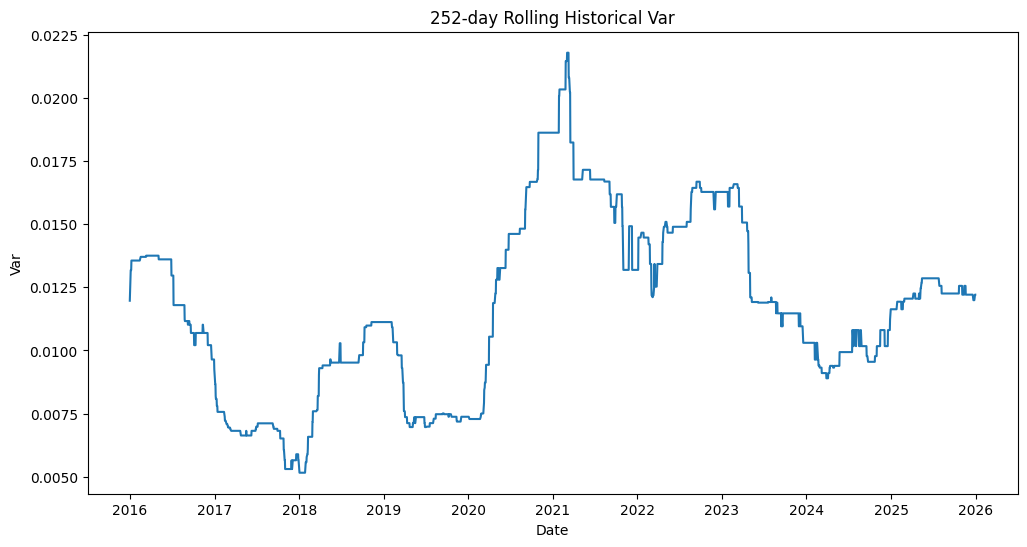

In [7]:
es = risk.calculate_expected_shortfall(strategy_returns)
historical_var = risk.calculate_historical_var(strategy_returns)
parametric_var = risk.calculate_parametric_var(strategy_returns)

rolling_var = risk.calculate_rolling_var(strategy_returns)

risk.plot_rolling_var(rolling_var)

controlled_returns = risk.apply_risk_control(strategy_returns,rolling_var)

6. backtesting

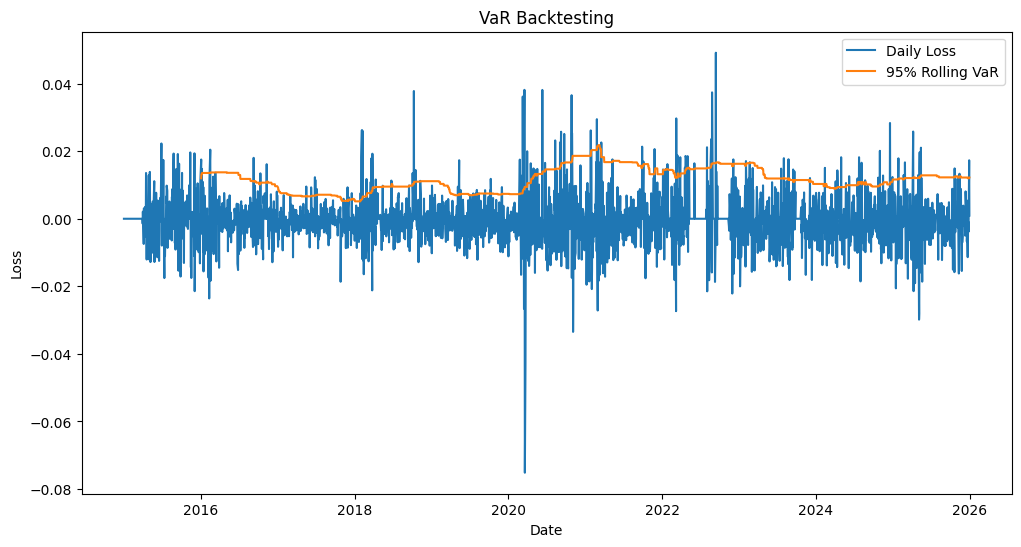

{'Breach Count': np.int64(136), 'Breach Rate': np.float64(0.04918625678119349)}
Date
2022-09-13    0.049160
2020-03-18    0.038167
2020-06-11    0.038138
2018-10-10    0.037821
2022-08-26    0.037418
dtype: float64


In [8]:
breaches = bt.calculate_var_breaches(strategy_returns,rolling_var)
summary = bt.backtest_summary(breaches)
bt.plot_var_backtest(strategy_returns,rolling_var)
largest = bt.largest_breaches(strategy_returns,rolling_var)
print(summary)
print(largest)

7. stress testing

In [ ]:

scenarios = st.stress_scenarios()
current_weights = weights.iloc[-1]
stress_result = st.run_stress_test(
    current_weights,
    tickers,
    scenarios
)

print(stress_result)

Equity Selloff    -0.043333
Rates Shock       -0.010000
Crisis Risk-Off   -0.046667
Inflation Shock   -0.013333
Name: Portfolio Return, dtype: float64
